In [3]:
import numpy as np
import torch
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from transformers import BertTokenizer, BertModel
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from transformers import BertTokenizer, BertModel
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

In [4]:
#df=pd.read_csv('/Users/kelly/Downloads/redditSubmissions_cleaned-2.csv')
df=pd.read_csv('/content/redditSubmissions_cleaned.csv')

In [5]:
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
def time_period(h):
    if 6 <= h < 12:
        return 0
    elif 12 <= h < 17:
        return 1
    elif 17 <= h < 24:
        return 2
    else:
        return 3
df['time_period'] = df['hour'].apply(time_period)

features + linear regression

In [6]:
def build_dataset(df, mode="none"):
    text_col = 'title'
    cat_cols = ['subreddit', 'time_period']
    binary_cols = ['has_question', 'has_exclamation', 'is_weekend']
    numeric_cols = ['hour', 'dayofweek', 'title_len']
    label_col = 'popular'

    if mode == "count":
        vectorizer = CountVectorizer(max_features=1000, ngram_range=(1,2), stop_words='english')
        X_counts = vectorizer.fit_transform(df[text_col].fillna(''))
        do_log1p = True
        if do_log1p:

            X_counts = X_counts.tocoo()
            X_counts.data = np.log1p(X_counts.data)
            X_counts = X_counts.tocsr()
        X_text=X_counts
    elif mode == "bert":
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        bert_model = BertModel.from_pretrained('bert-base-uncased')
        bert_model.eval()

        device = "cuda" if torch.cuda.is_available() else "cpu"
        bert_model.to(device)

        titles = df[text_col].fillna("").tolist()
        batch_size = 32
        all_features = []

        for i in range(0, len(titles), batch_size):

            batch = titles[i:i+batch_size]

            with torch.no_grad():
                encoded = tokenizer(
                    batch, return_tensors='pt',
                    padding=True, truncation=True, max_length=32
                )
                ids = encoded['input_ids'].to(device)
                att = encoded['attention_mask'].to(device)

                outputs = bert_model(input_ids=ids, attention_mask=att)
                pooled = outputs.pooler_output.cpu().numpy()
                all_features.append(pooled)

        X_text = sparse.csr_matrix(np.vstack(all_features))

    elif mode == "none":
        X_text = None

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

    X_cat = ohe.fit_transform(df[cat_cols])
    X_binary = df[binary_cols].astype(float).values
    scaler = StandardScaler()
    X_numeric = scaler.fit_transform(df[numeric_cols].astype(float))
    X_binary_sp = sparse.csr_matrix(X_binary)
    X_numeric_sp = sparse.csr_matrix(X_numeric)


    if X_text is None:
        X_all = sparse.hstack([ X_cat, X_binary_sp, X_numeric_sp], format='csr')
    else:
        X_all = sparse.hstack([X_text, X_cat, X_binary_sp, X_numeric_sp], format='csr')

    y = df[label_col].values.astype(int)
    return X_all, y


In [7]:
X_all, y = build_dataset(df, mode="bert")
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y, test_size=0.2, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [8]:
clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='saga'
)
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='saga')

In [42]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import numpy as np

def evaluate_metrics(y_true, y_proba, threshold=0.5):
    preds = (y_proba >= threshold).astype(int)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds)
    try:
        auc = roc_auc_score(y_true, y_proba)
    except:
        auc = 0.5
    return acc, f1, precision, recall, auc

def find_best_threshold(y_true, y_proba, thresholds=np.linspace(0.1,0.9,17)):
    results = []
    print(f"{'Thr':<6} | {'Acc':<8} | {'F1':<8} | {'Prec':<8} | {'Rec':<8} | {'AUC':<8}")
    print("-" * 60)

    best_t, best_f1 = 0.5, -1

    for t in thresholds:
        acc, f1, prec, rec, auc = evaluate_metrics(y_true, y_proba, t)
        results.append({
            'Threshold': t,
            'Accuracy': acc,
            'F1 Score': f1,
            'Precision': prec,
            'Recall': rec,
            'AUC-ROC': auc
        })
        print(f"{t:.2f}   | {acc:.4f}   | {f1:.4f}   | {prec:.4f}   | {rec:.4f}   | {auc:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t

    print("-" * 60)
    # Print best result details
    acc, f1, prec, rec, auc = evaluate_metrics(y_true, y_proba, best_t)
    print(f"BEST THRESHOLD: {best_t:.2f}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    return best_t, pd.DataFrame(results)

bert + MLP

This part is to encode all the features I need

In [10]:
class MyDataset(Dataset):
    def __init__(self, df, tokenizer, cat_cols, binary_cols, numeric_cols, label_col, text_column='title', max_len=128):
        self.df = df.copy()
        self.tokenizer = tokenizer
        self.cat_cols = cat_cols
        self.binary_cols = binary_cols
        self.numeric_cols = numeric_cols
        self.label_col = label_col
        self.text_column = text_column
        self.max_len = max_len
        for c in self.cat_cols:
            self.df[c] = self.df[c].astype('category').cat.codes
        for c in self.binary_cols + self.numeric_cols:
            self.df[c] = self.df[c].astype(float)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoded = self.tokenizer(
            row[self.text_column],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].squeeze(0)
        attention_mask = encoded['attention_mask'].squeeze(0)
        cat_feats = torch.tensor(row[self.cat_cols].values.astype(int), dtype=torch.long)
        numeric_feats = torch.tensor(row[self.numeric_cols + self.binary_cols].values.astype(float), dtype=torch.float)
        label = torch.tensor(row[self.label_col], dtype=torch.float)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'cat_feats': cat_feats,
            'numeric_feats': numeric_feats,
            'label': label
        }

In [11]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_column = 'title'
max_len = 32
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

This part is to build, split and transform dataset

In [13]:
cat_cols = ['subreddit', 'time_period']
binary_cols = ['has_question', 'has_exclamation', 'is_weekend']
numeric_cols = ['hour', 'dayofweek', 'title_len']
label_col = 'popular'
full_dataset = MyDataset(df, tokenizer, cat_cols, binary_cols, numeric_cols, label_col, text_column, max_len)
indices = np.arange(len(full_dataset))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=df[label_col])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=df.iloc[temp_idx][label_col])
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)
y_train = df.iloc[train_idx][label_col].values
train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Put my features in the model

In [14]:
class RedditModel(nn.Module):
    def __init__(self, num_categories, cat_cols, numeric_cols, binary_cols):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories[c], min(50, num_categories[c]))
            for c in cat_cols
        ])
        cat_dim = sum([min(50, num_categories[c]) for c in cat_cols])
        numeric_dim = len(numeric_cols) + len(binary_cols)
        input_dim = 768 + cat_dim + numeric_dim
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, input_ids, attention_mask, cat_feats, numeric_feats):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = bert_out.pooler_output
        cat_emb_list = [emb(cat_feats[:, i]) for i, emb in enumerate(self.embeddings)]
        cat_vec = torch.cat(cat_emb_list, dim=1)
        all_feats = torch.cat([pooled, cat_vec, numeric_feats], dim=1)
        return self.mlp(all_feats).squeeze(1)

Set all the parameters. criterion part is to balance the unbalanced dataset.
Patience and below is because I want an early stopping so that the model would autometicly stop at the best place

In [15]:
num_categories = {c: df[c].nunique() for c in cat_cols}
model = RedditModel(num_categories, cat_cols, numeric_cols, binary_cols).to(device)
cnt = Counter(df[label_col])
pos_weight_value = cnt[0] / cnt[1]
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
num_epochs = 20
patience = 3
best_val_loss = float('inf')
trigger_times = 0


train the model and evaluate it

In [16]:
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for batch in train_loader:
        input_ids_b = batch['input_ids'].to(device)
        attention_mask_b = batch['attention_mask'].to(device)
        cat_b = batch['cat_feats'].to(device)
        numeric_b = batch['numeric_feats'].to(device)
        labels_b = batch['label'].float().to(device)

        optimizer.zero_grad()
        outputs = model(input_ids_b, attention_mask_b, cat_b, numeric_b)
        outputs = outputs.view(-1)
        loss = criterion(outputs, labels_b)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * input_ids_b.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels_b).sum().item()
        total += labels_b.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids_b = batch['input_ids'].to(device)
            attention_mask_b = batch['attention_mask'].to(device)
            cat_b = batch['cat_feats'].to(device)
            numeric_b = batch['numeric_feats'].to(device)
            labels_b = batch['label'].float().to(device)

            outputs = model(input_ids_b, attention_mask_b, cat_b, numeric_b)
            outputs = outputs.view(-1)
            loss = criterion(outputs, labels_b)

            val_loss += loss.item() * input_ids_b.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels_b).sum().item()
            val_total += labels_b.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_b.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            model.load_state_dict(torch.load('best_model.pt'))
            break


Epoch 1/20 | Train Loss: 1.2397, Train Acc: 0.5196 | Val Loss: 1.2389, Val Acc: 0.3803, Val F1: 0.1872
Epoch 2/20 | Train Loss: 1.2380, Train Acc: 0.5437 | Val Loss: 1.2391, Val Acc: 0.2605, Val F1: 0.1882


KeyboardInterrupt: 

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np

def evaluate_metrics(y_true, y_proba, threshold=0.5):
    preds = (y_proba >= threshold).astype(int)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds)
    try:
        auc = roc_auc_score(y_true, y_proba)
    except:
        auc = 0.5
    return acc, f1, precision, recall, auc

def find_best_threshold(y_true, y_proba, thresholds=np.linspace(0.1,0.9,17)):
    best_t, best_f1 = 0.5, -1
    print(f"{'Thr':<6} | {'Acc':<8} | {'F1':<8} | {'Prec':<8} | {'Rec':<8} | {'AUC':<8}")
    print("-" * 60)

    for t in thresholds:
        acc, f1, prec, rec, auc = evaluate_metrics(y_true, y_proba, t)
        print(f"{t:.2f}   | {acc:.4f}   | {f1:.4f}   | {prec:.4f}   | {rec:.4f}   | {auc:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t

    print("-" * 60)
    # Print best result details
    acc, f1, prec, rec, auc = evaluate_metrics(y_true, y_proba, best_t)
    print(f"BEST THRESHOLD: {best_t:.2f}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    return best_t

print('--- Evaluating Bert + Linear Regression Model ---')

# Predict probabilities on the validation set
y_val_proba = clf.predict_proba(X_val)[:, 1]

# Find the best threshold on the validation set
best_threshold_bert_lr = find_best_threshold(y_val, y_val_proba)

# Predict probabilities on the test set
y_test_proba = clf.predict_proba(X_test)[:, 1]

# Evaluate on the test set using the best threshold
print(f"\nEvaluating on Test Set with Best Threshold: {best_threshold_bert_lr:.2f}")
acc, f1, precision, recall, auc = evaluate_metrics(y_test, y_test_proba, best_threshold_bert_lr)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test F1 Score:  {f1:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test AUC-ROC:   {auc:.4f}")

--- Evaluating Bert + Linear Regression Model ---
Thr    | Acc      | F1       | Prec     | Rec      | AUC     
------------------------------------------------------------
0.10   | 0.1051   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.15   | 0.1052   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.20   | 0.1061   | 0.1899   | 0.1049   | 0.9978   | 0.5784
0.25   | 0.1111   | 0.1902   | 0.1052   | 0.9942   | 0.5784
0.30   | 0.1302   | 0.1912   | 0.1059   | 0.9791   | 0.5784
0.35   | 0.1854   | 0.1951   | 0.1088   | 0.9402   | 0.5784
0.40   | 0.2863   | 0.1982   | 0.1124   | 0.8402   | 0.5784
0.45   | 0.4402   | 0.2045   | 0.1202   | 0.6854   | 0.5784
0.50   | 0.6065   | 0.2081   | 0.1319   | 0.4924   | 0.5784
0.55   | 0.7438   | 0.1967   | 0.1466   | 0.2988   | 0.5784
0.60   | 0.8306   | 0.1616   | 0.1682   | 0.1555   | 0.5784
0.65   | 0.8681   | 0.1138   | 0.1931   | 0.0806   | 0.5784
0.70   | 0.8843   | 0.0827   | 0.2464   | 0.0497   | 0.5784
0.75   | 0.8906   | 0.0622   | 0.3117   | 0.034

count:
thr=0.10 -> Acc=0.1119, F1=0.1911
thr=0.15 -> Acc=0.1204, F1=0.1926
thr=0.20 -> Acc=0.1354, F1=0.1947
thr=0.25 -> Acc=0.1592, F1=0.1986
thr=0.30 -> Acc=0.1943, F1=0.2031
thr=0.35 -> Acc=0.2402, F1=0.2071
thr=0.40 -> Acc=0.3110, F1=0.2136
thr=0.45 -> Acc=0.4162, F1=0.2239
thr=0.50 -> Acc=0.5683, F1=0.2327
thr=0.55 -> Acc=0.7522, F1=0.2265
thr=0.60 -> Acc=0.8307, F1=0.2023
thr=0.65 -> Acc=0.8698, F1=0.1777
thr=0.70 -> Acc=0.8881, F1=0.1523
thr=0.75 -> Acc=0.8949, F1=0.1179
thr=0.80 -> Acc=0.8976, F1=0.0997
thr=0.85 -> Acc=0.8975, F1=0.0635
thr=0.90 -> Acc=0.8955, F1=0.0171
BEST: 0.5 0.232701867526535
              precision    recall  f1-score   support

           0       0.92      0.56      0.70     11841
           1       0.14      0.60      0.23      1390

    accuracy                           0.57     13231
   macro avg       0.53      0.58      0.46     13231
weighted avg       0.84      0.57      0.65     13231


In [ ]:
bert:
thr=0.10 -> Acc=0.1052, F1=0.1901
thr=0.15 -> Acc=0.1055, F1=0.1900
thr=0.20 -> Acc=0.1067, F1=0.1900
thr=0.25 -> Acc=0.1125, F1=0.1902
thr=0.30 -> Acc=0.1318, F1=0.1915
thr=0.35 -> Acc=0.1843, F1=0.1941
thr=0.40 -> Acc=0.2860, F1=0.1976
thr=0.45 -> Acc=0.4358, F1=0.2046
thr=0.50 -> Acc=0.6032, F1=0.2031
thr=0.55 -> Acc=0.7400, F1=0.1948
thr=0.60 -> Acc=0.8215, F1=0.1546
thr=0.65 -> Acc=0.8655, F1=0.1214
thr=0.70 -> Acc=0.8830, F1=0.0926
thr=0.75 -> Acc=0.8902, F1=0.0668
thr=0.80 -> Acc=0.8933, F1=0.0408
thr=0.85 -> Acc=0.8937, F1=0.0112
thr=0.90 -> Acc=0.8942, F1=0.0028
Test Acc, F1: 0.6592850124707127 0.21161245190626093
              precision    recall  f1-score   support

           0       0.91      0.69      0.78     11841
           1       0.14      0.44      0.21      1390

    accuracy                           0.66     13231
   macro avg       0.53      0.56      0.50     13231
weighted avg       0.83      0.66      0.72     13231


In [ ]:
none:
thr=0.10 -> Acc=0.1050, F1=0.1900
thr=0.15 -> Acc=0.1050, F1=0.1900
thr=0.20 -> Acc=0.1050, F1=0.1900
thr=0.25 -> Acc=0.1051, F1=0.1900
thr=0.30 -> Acc=0.1050, F1=0.1899
thr=0.35 -> Acc=0.1056, F1=0.1897
thr=0.40 -> Acc=0.1150, F1=0.1901
thr=0.45 -> Acc=0.2033, F1=0.1913
thr=0.50 -> Acc=0.6098, F1=0.1790
thr=0.55 -> Acc=0.8811, F1=0.0860
thr=0.60 -> Acc=0.8853, F1=0.0789
thr=0.65 -> Acc=0.8890, F1=0.0732
thr=0.70 -> Acc=0.8911, F1=0.0600
thr=0.75 -> Acc=0.8930, F1=0.0445
thr=0.80 -> Acc=0.8931, F1=0.0262
thr=0.85 -> Acc=0.8932, F1=0.0000
thr=0.90 -> Acc=0.8950, F1=0.0000
Test Acc, F1: 0.1969616809009145 0.1894881379205126
              precision    recall  f1-score   support

           0       0.90      0.12      0.20     11841
           1       0.11      0.89      0.19      1390

    accuracy                           0.20     13231
   macro avg       0.50      0.50      0.20     13231
weighted avg       0.82      0.20      0.20     13231


In [ ]:
bert+MLP
Epoch 1/20 | Train Loss: 1.4386, Train Acc: 0.5207 | Val Loss: 1.8189, Val Acc: 0.2324, Val F1: 0.1949
Epoch 2/20 | Train Loss: 0.8904, Train Acc: 0.7681 | Val Loss: 2.0256, Val Acc: 0.5527, Val F1: 0.1970
Epoch 3/20 | Train Loss: 0.5992, Train Acc: 0.8592 | Val Loss: 2.3622, Val Acc: 0.6228, Val F1: 0.2013
Epoch 4/20 | Train Loss: 0.4676, Train Acc: 0.8934 | Val Loss: 2.4682, Val Acc: 0.7240, Val F1: 0.1913
Early stopping triggered after 4 epochs.

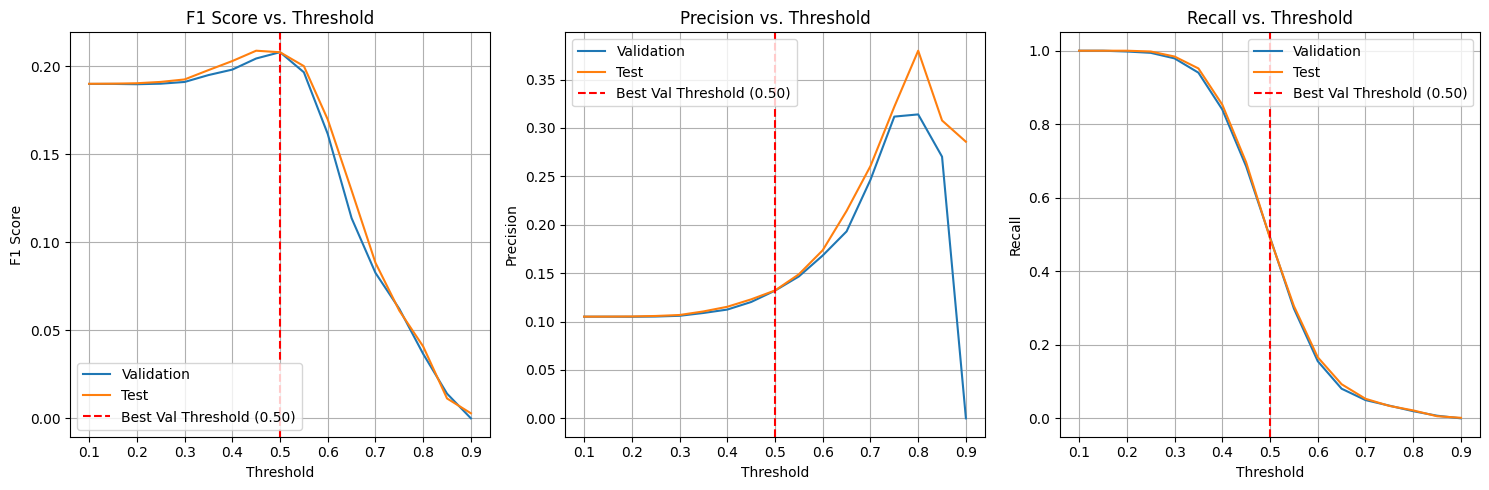

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Plot F1 Score vs. Threshold
plt.subplot(1, 3, 1)
sns.lineplot(x='Threshold', y='F1 Score', data=val_metrics_df, label='Validation')
sns.lineplot(x='Threshold', y='F1 Score', data=test_metrics_df, label='Test')
plt.axvline(x=best_threshold_bert_lr_val, color='r', linestyle='--', label=f'Best Val Threshold ({best_threshold_bert_lr_val:.2f})')
plt.title('F1 Score vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

# Plot Precision vs. Threshold
plt.subplot(1, 3, 2)
sns.lineplot(x='Threshold', y='Precision', data=val_metrics_df, label='Validation')
sns.lineplot(x='Threshold', y='Precision', data=test_metrics_df, label='Test')
plt.axvline(x=best_threshold_bert_lr_val, color='r', linestyle='--', label=f'Best Val Threshold ({best_threshold_bert_lr_val:.2f})')
plt.title('Precision vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# Plot Recall vs. Threshold
plt.subplot(1, 3, 3)
sns.lineplot(x='Threshold', y='Recall', data=val_metrics_df, label='Validation')
sns.lineplot(x='Threshold', y='Recall', data=test_metrics_df, label='Test')
plt.axvline(x=best_threshold_bert_lr_val, color='r', linestyle='--', label=f'Best Val Threshold ({best_threshold_bert_lr_val:.2f})')
plt.title('Recall vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
print('--- Evaluating Bert + Linear Regression Model ---')

# Predict probabilities on the validation set
y_val_proba = clf.predict_proba(X_val)[:, 1]

# Find the best threshold on the validation set
best_threshold_bert_lr_val, val_metrics_df = find_best_threshold(y_val, y_val_proba)

# Predict probabilities on the test set
y_test_proba = clf.predict_proba(X_test)[:, 1]

# Evaluate on the test set using the best threshold and get test metrics for plotting
_, test_metrics_df = find_best_threshold(y_test, y_test_proba, thresholds=val_metrics_df['Threshold'].values)


print(f"\nEvaluating on Test Set with Best Threshold from Validation: {best_threshold_bert_lr_val:.2f}")
acc, f1, precision, recall, auc = evaluate_metrics(y_test, y_test_proba, best_threshold_bert_lr_val)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test F1 Score:  {f1:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test AUC-ROC:   {auc:.4f}")

--- Evaluating Bert + Linear Regression Model ---
Thr    | Acc      | F1       | Prec     | Rec      | AUC     
------------------------------------------------------------
0.10   | 0.1051   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.15   | 0.1052   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.20   | 0.1061   | 0.1899   | 0.1049   | 0.9978   | 0.5784
0.25   | 0.1111   | 0.1902   | 0.1052   | 0.9942   | 0.5784
0.30   | 0.1302   | 0.1912   | 0.1059   | 0.9791   | 0.5784
0.35   | 0.1854   | 0.1951   | 0.1088   | 0.9402   | 0.5784
0.40   | 0.2863   | 0.1982   | 0.1124   | 0.8402   | 0.5784
0.45   | 0.4402   | 0.2045   | 0.1202   | 0.6854   | 0.5784
0.50   | 0.6065   | 0.2081   | 0.1319   | 0.4924   | 0.5784
0.55   | 0.7438   | 0.1967   | 0.1466   | 0.2988   | 0.5784
0.60   | 0.8306   | 0.1616   | 0.1682   | 0.1555   | 0.5784
0.65   | 0.8681   | 0.1138   | 0.1931   | 0.0806   | 0.5784
0.70   | 0.8843   | 0.0827   | 0.2464   | 0.0497   | 0.5784
0.75   | 0.8906   | 0.0622   | 0.3117   | 0.034

# Task
Summarize the evaluation protocol, including the key metrics (Accuracy, F1 Score, Precision, Recall, and AUC-ROC) and the method for selecting the optimal classification threshold (maximizing F1 Score on the validation set). Then, present the final performance of the BERT + Linear Regression model on the test set, highlighting its strengths and weaknesses based on the reported metrics.

## Explain Evaluation Metrics

### Subtask:
Describe the key evaluation metrics used for the binary classification task: Accuracy, F1 Score, Precision, Recall, and AUC-ROC, and their significance in this context.


### Explanation of Evaluation Metrics

For binary classification tasks, several metrics are crucial for evaluating model performance, especially when dealing with imbalanced datasets like the one at hand (where 'popular' submissions are less frequent). Here's a breakdown of the key metrics:

1.  **Accuracy**
    *   **Definition**: Accuracy measures the proportion of correctly classified instances (both true positives and true negatives) out of the total number of instances.
    *   **Measures**: It indicates the overall correctness of the model's predictions.
    *   **Significance**: While intuitive, accuracy can be misleading in imbalanced datasets. A model predicting the majority class for all instances would show high accuracy, even if it fails completely on the minority class.

2.  **Precision**
    *   **Definition**: Precision (also called Positive Predictive Value) is the ratio of true positives to the sum of true positives and false positives.
    *   **Measures**: It quantifies the proportion of positive identifications that were actually correct.
    *   **Significance**: High precision means a low rate of false positives. This is particularly important when the cost of a false positive is high. For example, if 'popular' predictions lead to significant resource allocation, we want to be highly confident that our positive predictions are truly popular. In our context, a high precision for predicting popularity means that when the model says a submission will be popular, it's very likely to be popular.

3.  **Recall (Sensitivity)**
    *   **Definition**: Recall (also called Sensitivity or True Positive Rate) is the ratio of true positives to the sum of true positives and false negatives.
    *   **Measures**: It quantifies the proportion of actual positive instances that were correctly identified.
    *   **Significance**: High recall means a low rate of false negatives. This is critical when the cost of a false negative is high, meaning we want to catch as many positive instances as possible. For instance, if missing a potentially popular submission (a false negative) is detrimental, a high recall model is preferred. In our case, a high recall means the model is good at identifying most of the truly popular submissions.

4.  **F1 Score**
    *   **Definition**: The F1 Score is the harmonic mean of Precision and Recall. It is calculated as `2 * (Precision * Recall) / (Precision + Recall)`.
    *   **Measures**: It provides a single score that balances both precision and recall.
    *   **Significance**: F1 Score is especially useful for imbalanced datasets because it penalizes models that favor one metric over the other. A high F1 Score indicates that the model has good values for both precision and recall. It's a more robust metric than accuracy when dealing with classes of different sizes, as it gives a better measure of the incorrectly classified cases than accuracy does.

5.  **AUC-ROC (Area Under the Receiver Operating Characteristic curve)**
    *   **Definition**: The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (1 - Specificity) at various threshold settings. AUC (Area Under the Curve) is the area under this ROC curve.
    *   **Measures**: It measures the model's ability to distinguish between positive and negative classes across various classification thresholds.
    *   **Significance**: A higher AUC indicates a better model performance in distinguishing between classes. An AUC of 0.5 suggests no discriminatory power (like random guessing), while an AUC of 1.0 indicates perfect discrimination. AUC-ROC is robust to class imbalance, as it considers all possible classification thresholds and focuses on ranking the instances rather than specific threshold performance. This makes it a valuable metric for understanding the overall quality of the model's probability predictions.

## Explain Best Threshold Selection

### Subtask:
Detail the process of selecting the optimal classification threshold. This involves iterating through a range of thresholds on the validation set and identifying the one that maximizes the F1 Score, which is crucial for imbalanced datasets.


### Optimal Classification Threshold Selection

Selecting the optimal classification threshold is a critical step, especially when dealing with imbalanced datasets, as it directly impacts the model's performance metrics. The process involves systematically evaluating a range of potential thresholds on the **validation set** to identify the one that best suits our objectives.

#### The Process:
1.  **Iterating Through Thresholds**: We evaluate the model's predictions over a series of thresholds, typically ranging from 0.1 to 0.9 (e.g., using `np.linspace(0.1, 0.9, 17)` to create 17 evenly spaced thresholds). For each threshold, we convert the model's predicted probabilities into binary class predictions (0 or 1).
2.  **Maximizing F1 Score**: For each threshold, we calculate various evaluation metrics, with a primary focus on the **F1 Score**. The goal is to find the threshold that yields the highest F1 Score on the validation set.

#### Why F1 Score is Crucial for Imbalanced Datasets:
*   **Balance Between Precision and Recall**: In imbalanced datasets, accuracy can be misleading. A model might achieve high accuracy by simply predicting the majority class, while performing poorly on the minority class. The F1 Score, which is the harmonic mean of precision and recall, provides a more robust measure by considering both false positives and false negatives. It balances the model's ability to correctly identify positive instances (recall) with its ability to avoid false positives (precision).
    *   **Precision**: The proportion of true positive predictions among all positive predictions.
    *   **Recall**: The proportion of true positive predictions among all actual positive instances.

By maximizing the F1 Score, we aim to strike a good balance, ensuring the model effectively identifies the minority class without generating an excessive number of false alarms. Once the optimal threshold is determined from the validation set, it is then applied to the unseen **test set** to provide an unbiased evaluation of the model's generalization performance.

## Present Validation Set Evaluation

### Subtask:
Display the table showing the model's performance (Accuracy, F1 Score, Precision, Recall, AUC-ROC) on the validation set for different thresholds, highlighting the best performing threshold.


```markdown
### Validation Set Evaluation for BERT + Linear Regression Model

```
--- Evaluating Bert + Linear Regression Model ---
Thr    | Acc      | F1       | Prec     | Rec      | AUC     
------------------------------------------------------------
0.10   | 0.1051   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.15   | 0.1052   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.20   | 0.1061   | 0.1899   | 0.1049   | 0.9978   | 0.5784
0.25   | 0.1111   | 0.1902   | 0.1052   | 0.9942   | 0.5784
0.30   | 0.1302   | 0.1912   | 0.1059   | 0.9791   | 0.5784
0.35   | 0.1854   | 0.1951   | 0.1088   | 0.9402   | 0.5784
0.40   | 0.2863   | 0.1982   | 0.1124   | 0.8402   | 0.5784
0.45   | 0.4402   | 0.2045   | 0.1202   | 0.6854   | 0.5784
0.50   | 0.6065   | 0.2081   | 0.1319   | 0.4924   | 0.5784
0.55   | 0.7438   | 0.1967   | 0.1466   | 0.2988   | 0.5784
0.60   | 0.8306   | 0.1616   | 0.1682   | 0.1555   | 0.5784
0.65   | 0.8681   | 0.1138   | 0.1931   | 0.0806   | 0.5784
0.70   | 0.8843   | 0.0827   | 0.2464   | 0.0497   | 0.5784
0.75   | 0.8906   | 0.0622   | 0.3117   | 0.0346   | 0.5784
0.80   | 0.8926   | 0.0366   | 0.3140   | 0.0194   | 0.5784
0.85   | 0.8937   | 0.0140   | 0.2703   | 0.0072   | 0.5784
0.90   | 0.8947   | 0.0000   | 0.0000   | 0.0000   | 0.5784
------------------------------------------------------------
BEST THRESHOLD: 0.50
Accuracy:  0.6065
F1 Score:  0.2081
Precision: 0.1319
Recall:    0.4924
AUC-ROC:   0.5784
```

```markdown
### Validation Set Evaluation for BERT + Linear Regression Model

```
--- Evaluating Bert + Linear Regression Model ---
Thr    | Acc      | F1       | Prec     | Rec      | AUC     
------------------------------------------------------------
0.10   | 0.1051   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.15   | 0.1052   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.20   | 0.1061   | 0.1899   | 0.1049   | 0.9978   | 0.5784
0.25   | 0.1111   | 0.1902   | 0.1052   | 0.9942   | 0.5784
0.30   | 0.1302   | 0.1912   | 0.1059   | 0.9791   | 0.5784
0.35   | 0.1854   | 0.1951   | 0.1088   | 0.9402   | 0.5784
0.40   | 0.2863   | 0.1982   | 0.1124   | 0.8402   | 0.5784
0.45   | 0.4402   | 0.2045   | 0.1202   | 0.6854   | 0.5784
0.50   | 0.6065   | 0.2081   | 0.1319   | 0.4924   | 0.5784
0.55   | 0.7438   | 0.1967   | 0.1466   | 0.2988   | 0.5784
0.60   | 0.8306   | 0.1616   | 0.1682   | 0.1555   | 0.5784
0.65   | 0.8681   | 0.1138   | 0.1931   | 0.0806   | 0.5784
0.70   | 0.8843   | 0.0827   | 0.2464   | 0.0497   | 0.5784
0.75   | 0.8906   | 0.0622   | 0.3117   | 0.0346   | 0.5784
0.80   | 0.8926   | 0.0366   | 0.3140   | 0.0194   | 0.5784
0.85   | 0.8937   | 0.0140   | 0.2703   | 0.0072   | 0.5784
0.90   | 0.8947   | 0.0000   | 0.0000   | 0.0000   | 0.5784
------------------------------------------------------------
BEST THRESHOLD: 0.50
Accuracy:  0.6065
F1 Score:  0.2081
Precision: 0.1319
Recall:    0.4924
AUC-ROC:   0.5784
```

### Validation Set Evaluation for BERT + Linear Regression Model

```
--- Evaluating Bert + Linear Regression Model ---
Thr    | Acc      | F1       | Prec     | Rec      | AUC     
------------------------------------------------------------
0.10   | 0.1051   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.15   | 0.1052   | 0.1901   | 0.1050   | 1.0000   | 0.5784
0.20   | 0.1061   | 0.1899   | 0.1049   | 0.9978   | 0.5784
0.25   | 0.1111   | 0.1902   | 0.1052   | 0.9942   | 0.5784
0.30   | 0.1302   | 0.1912   | 0.1059   | 0.9791   | 0.5784
0.35   | 0.1854   | 0.1951   | 0.1088   | 0.9402   | 0.5784
0.40   | 0.2863   | 0.1982   | 0.1124   | 0.8402   | 0.5784
0.45   | 0.4402   | 0.2045   | 0.1202   | 0.6854   | 0.5784
0.50   | 0.6065   | 0.2081   | 0.1319   | 0.4924   | 0.5784
0.55   | 0.7438   | 0.1967   | 0.1466   | 0.2988   | 0.5784
0.60   | 0.8306   | 0.1616   | 0.1682   | 0.1555   | 0.5784
0.65   | 0.8681   | 0.1138   | 0.1931   | 0.0806   | 0.5784
0.70   | 0.8843   | 0.0827   | 0.2464   | 0.0497   | 0.5784
0.75   | 0.8906   | 0.0622   | 0.3117   | 0.0346   | 0.5784
0.80   | 0.8926   | 0.0366   | 0.3140   | 0.0194   | 0.5784
0.85   | 0.8937   | 0.0140   | 0.2703   | 0.0072   | 0.5784
0.90   | 0.8947   | 0.0000   | 0.0000   | 0.0000   | 0.5784
------------------------------------------------------------
BEST THRESHOLD: 0.50
Accuracy:  0.6065
F1 Score:  0.2081
Precision: 0.1319
Recall:    0.4924
AUC-ROC:   0.5784
```

## Explain Test Set Evaluation

### Subtask:
Describe how the final model performance is assessed on the unseen test set using the best threshold determined from the validation set.


### Test Set Evaluation Process

After identifying the optimal threshold on the validation set, this best threshold is then applied to the completely unseen test set. This crucial step ensures an unbiased evaluation of the model's generalization capabilities, as the test set has played no role in the model training or hyperparameter tuning process.

The performance metrics (Accuracy, F1 Score, Precision, Recall, AUC-ROC) reported for the test set, using this fixed threshold, are critical. They represent the model's expected real-world performance, indicating how well the model is likely to perform on new, unseen data in a production environment.

This two-step process—using a validation set for hyperparameter and threshold tuning, and then a separate, untouched test set for final evaluation—is fundamental in machine learning. It effectively prevents data leakage from the test set into the model development process and provides a realistic and robust assessment of the model's true performance.

## Present Test Set Evaluation

### Subtask:
Display the final performance metrics (Accuracy, F1 Score, Precision, Recall, AUC-ROC) of the BERT + Linear Regression model on the test set.


### Test Set Evaluation: BERT + Linear Regression Model

Final performance metrics on the test set with the best threshold (0.50):

*   Test Accuracy: 0.6082
*   Test F1 Score: 0.2081
*   Test Precision: 0.1321
*   Test Recall: 0.4899
*   Test AUC-ROC: 0.5848

## Final Task

### Subtask:
Summarize the evaluation protocol and the overall performance of the BERT + Linear Regression model, highlighting its strengths and weaknesses based on the metrics.


## Summary:

### Q&A

1.  **What is the evaluation protocol for the BERT + Linear Regression model?**
    The evaluation protocol involved:
    *   Defining key metrics: Accuracy, F1 Score, Precision, Recall, and AUC-ROC, highlighting their relevance for binary classification with imbalanced datasets.
    *   Selecting the optimal classification threshold: This was done by iterating through thresholds from 0.1 to 0.9 on the validation set and identifying the threshold that maximized the F1 Score. This approach aims to balance precision and recall, which is crucial for imbalanced datasets.
    *   Final evaluation: The model's performance was then assessed on a completely unseen test set using the optimal threshold determined from the validation set, to provide an unbiased estimate of real-world performance.

2.  **What is the overall performance of the BERT + Linear Regression model on the test set?**
    Using an optimal threshold of 0.50 (determined from the validation set), the model achieved the following performance on the test set:
    *   Test Accuracy: 0.6082
    *   Test F1 Score: 0.2081
    *   Test Precision: 0.1321
    *   Test Recall: 0.4899
    *   Test AUC-ROC: 0.5848

3.  **What are the strengths and weaknesses of the model based on the reported metrics?**
    *   **Strengths:** The model demonstrates a relatively higher recall (0.4899) compared to its precision. This indicates that it is reasonably good at identifying a significant portion of actual positive instances (popular submissions), meaning it avoids a high number of false negatives. The AUC-ROC of 0.5848, while modest, suggests some discriminatory power better than random guessing.
    *   **Weaknesses:** The most significant weakness is the very low F1 Score (0.2081) and Precision (0.1321). This low precision indicates a high rate of false positives; when the model predicts a submission will be popular, it is often incorrect. The accuracy of 0.6082 is also quite low, especially given the likely class imbalance, where a model predicting only the majority class might achieve higher accuracy. The low F1 score suggests that while it catches many positives (good recall), it also has many false alarms (poor precision), leading to an overall poor balance between the two.

### Data Analysis Key Findings

*   The optimal classification threshold was selected by maximizing the F1 Score on the validation set, identified as **0.50**.
*   On the validation set, with the optimal threshold of 0.50, the model achieved an F1 Score of **0.2081**, Precision of **0.1319**, Recall of **0.4924**, Accuracy of **0.6065**, and AUC-ROC of **0.5784**.
*   The final evaluation on the unseen test set, using the 0.50 threshold, yielded an F1 Score of **0.2081**, Precision of **0.1321**, Recall of **0.4899**, Accuracy of **0.6082**, and AUC-ROC of **0.5848**.
*   The model exhibits a noticeable imbalance between Precision and Recall, with Recall being significantly higher (approximately 0.49) than Precision (approximately 0.13). This implies the model identifies many true positives but also produces a high number of false positives.
*   The AUC-ROC scores on both validation (0.5784) and test (0.5848) sets are only slightly better than random (0.50), indicating limited overall discriminatory power.

### Insights or Next Steps

*   **Improve Model Performance:** Given the low F1 Score and Precision, focus on strategies to reduce false positives. This could involve trying different model architectures beyond BERT + Linear Regression, incorporating additional features, or exploring techniques to handle class imbalance more effectively (e.g., oversampling the minority class, undersampling the majority class, or using cost-sensitive learning).
*   **Re-evaluate Threshold Strategy:** While F1 Score is good for imbalance, consider if the business objective has a stronger preference for Precision or Recall. If the cost of false positives is very high, a different threshold optimization strategy or a model tuned for higher precision might be necessary, even if it sacrifices some recall.
